# STAC Tile Index

Run this notebook from the conda environment `analysis`.

Build a flat GeoJSON index of the PlanetScope (`PS`) tiles in the FloodPlanet STAC-like catalog, then plot the tile footprints.

In [1]:
import json, os
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
from shapely.geometry import box, shape

# Keep notebook execution rooted at the repo.
os.chdir("/workspace")

 
import contextily as ctx
 

path_d = {
    "catalog_dir": Path("/workspace/_inputs/stac_catalog/"),
    "index_fp": Path("/workspace/stac_catalog.geojson"),
    "csda_dates_fp": Path("/workspace/STAC/csda_dates.tsv"),
    "csda_dates_clean_fp": Path("/workspace/STAC/csda_dates_clean.json"),
}

print(f"geopandas={gpd.__version__}")
print(f"pandas={pd.__version__}")
print(f"contextily={'available' if ctx is not None else 'missing'}")

geopandas=1.1.2
pandas=3.0.0
contextily=available


## Index Helpers

In [2]:
def _resolve_catalog_dir(path_d):
    """Return the configured catalog directory."""
    if path_d["catalog_dir"].exists():
        return path_d["catalog_dir"]
    raise FileNotFoundError(f"Could not find STAC catalog: {path_d['catalog_dir']}")


def _pick_asset_href(assets, kind):
    """Select a likely asset href for the requested asset kind."""
    assert kind in {"ps", "labels"}, kind
    if not assets:
        return None

    ext_l = (".tif", ".tiff", ".jp2", ".png", ".jpg", ".jpeg", ".geojson", ".json")
    asset_rows = []
    for key, asset_d in assets.items():
        href = asset_d.get("href")
        if href is None:
            continue
        role_txt = " ".join(asset_d.get("roles", []))
        txt = f"{key} {asset_d.get('title', '')} {role_txt} {href}".lower()
        asset_rows.append({"key": key, "href": href, "txt": txt})

    if kind == "ps":
        for row in asset_rows:
            if any(term in row["txt"] for term in ["planet", "ps", "planetscope"]):
                if not any(term in row["txt"] for term in ["label", "mask", "annotation"]):
                    return row["href"]
        for row in asset_rows:
            if row["href"].lower().endswith(ext_l):
                if not any(term in row["txt"] for term in ["label", "mask", "annotation"]):
                    return row["href"]

    if kind == "labels":
        for row in asset_rows:
            if any(term in row["txt"] for term in ["label", "labels", "annotation", "mask"]):
                return row["href"]

    return None


def _get_feature_geometry(item_d):
    """Return a shapely geometry from the STAC-like item geometry or bbox."""
    if item_d.get("geometry"):
        return shape(item_d["geometry"])
    bbox = item_d.get("bbox")
    assert bbox is not None and len(bbox) == 4, bbox
    return box(*bbox)


def main_clean_csda_dates(path_d, event_l):
    """Clean the CSDA date table into an Event keyed JSON lookup."""
    assert path_d["csda_dates_fp"].exists(), path_d["csda_dates_fp"]
    assert len(event_l) > 0, event_l

    raw_df = pd.read_csv(path_d["csda_dates_fp"], sep="\t")
    clean_d = {event: "" for event in sorted(event_l)}

    for _, row in raw_df.iterrows():
        event = row.get("Event_Table2")
        if pd.isna(event) or event not in clean_d:
            continue
        dt = pd.to_datetime(row.get("PS_datetime"), errors="coerce")
        clean_d[event] = "" if pd.isna(dt) else dt.isoformat()

    path_d["csda_dates_clean_fp"].write_text(json.dumps(clean_d, indent=2))
    print(f"Wrote cleaned CSDA dates to {path_d['csda_dates_clean_fp']}")

    return clean_d


def main_join_csda_dates(path_d, gdf):
    """Join cleaned CSDA datetimes onto the flat STAC index by Event."""
    assert not gdf.empty, "Expected a non-empty index"

    clean_d = main_clean_csda_dates(path_d=path_d, event_l=gdf["Event"].dropna().unique().tolist())
    out_gdf = gdf.copy()
    out_gdf["PS_datetime"] = out_gdf["Event"].map(clean_d).fillna("")

    # Write the enriched index back to the flat GeoJSON.
    out_gdf.to_file(path_d["index_fp"], driver="GeoJSON")
    print(f"Wrote enriched index to {path_d['index_fp']}")

    return out_gdf


def main_build_ps_index(path_d, overwrite=False):
    """Scan the catalog and build a flat GeoJSON index for the PS tile items.

    Parameters
    ----------
    path_d : dict
        Dictionary holding the candidate catalog paths and output filepath.
    overwrite : bool, default=False
        If False, skip the scan and write when the output file already exists.

    Returns
    -------
    geopandas.GeoDataFrame
        Flat tile index with the requested columns.
    """
    assert isinstance(path_d, dict), type(path_d)
    assert "index_fp" in path_d, path_d

    if path_d["index_fp"].exists() and not overwrite:
        print(f"Index exists and overwrite=False, reading: {path_d['index_fp']}")
        return gpd.read_file(path_d["index_fp"])

    catalog_dir = _resolve_catalog_dir(path_d)
    assert catalog_dir.exists(), catalog_dir

    rec_l = []
    for fp in sorted(catalog_dir.glob("*/PS/*/*.json")):
        # Read each PS tile item and flatten the key metadata into one row.
        item_d = json.loads(fp.read_text())
        rel_parts = fp.relative_to(catalog_dir).parts
        geom = _get_feature_geometry(item_d)
        rec_l.append({
            "Event": rel_parts[0],
            "Chip_ID": item_d.get("id", fp.stem),
            "Image Source": "PS",
            "PS_href": _pick_asset_href(item_d.get("assets", {}), "ps"),
            "labels_href": _pick_asset_href(item_d.get("assets", {}), "labels"),
            "bbox": item_d.get("bbox"),
            "geometry": geom,
        })

    gdf = gpd.GeoDataFrame(rec_l, geometry="geometry", crs="EPSG:4326")
    assert not gdf.empty, "No PS tile items were found in the catalog"

    # Write a flat GeoJSON index for downstream lookups.
    gdf.to_file(path_d["index_fp"], driver="GeoJSON")
    print(f"Wrote {len(gdf):,} features to {path_d['index_fp']}")

    return gdf

## Build Or Read The Index

In [3]:
try:
    gdf = main_build_ps_index(path_d=path_d, overwrite=False)
    gdf = main_join_csda_dates(path_d=path_d, gdf=gdf)
    display(gdf.head(3))
    print(gdf[["Event", "Chip_ID", "Image Source", "PS_datetime"]].groupby(["Event", "PS_datetime"]).size().sort_values(ascending=False).head(10))
except (FileNotFoundError, PermissionError) as err:
    gdf = None
    print(err)

Skipping field bbox: unsupported OGR type: 3


Index exists and overwrite=False, reading: /workspace/stac_catalog.geojson
Wrote cleaned CSDA dates to /workspace/STAC/csda_dates_clean.json
Wrote enriched index to /workspace/stac_catalog.geojson


,Event,Chip_ID,Image Source,PS_href,labels_href,geometry,PS_datetime
0,Bangladesh,BGD_40_119,PS,../../../../Bangladesh/PS/BGD_40_119.tif,../../../../Bangladesh/labels/BGD_40_119.tif,"POLYGON ((91.47738 23.51751, 91.47738 23.54749...",2017-03-14T03:45:00
1,Bangladesh,BGD_43_99,PS,../../../../Bangladesh/PS/BGD_43_99.tif,../../../../Bangladesh/labels/BGD_43_99.tif,"POLYGON ((91.5673 24.117, 91.5673 24.14698, 91...",2017-03-14T03:45:00
2,Bangladesh,BGD_45_90,PS,../../../../Bangladesh/PS/BGD_45_90.tif,../../../../Bangladesh/labels/BGD_45_90.tif,"POLYGON ((91.62725 24.38677, 91.62725 24.41675...",2017-03-14T03:45:00


Event        PS_datetime        
Bolivia      2018-02-15T14:00:00    100
Cambodia     2018-08-04T03:05:00     20
Ghana        2018-09-19T10:03:00     20
Spain        2019-09-18T10:30:00     20
Somalia      2018-05-05T07:10:00     20
US-Kansas    2019-05-22T16:57:00     20
Paraguay     2018-10-31T13:31:00     18
US-Nebraska  2017-09-29T14:30:00     16
US-Alabama   2019-05-25T16:10:00     16
Bangladesh   2017-03-14T03:45:00     15
dtype: int64


## Tile Footprint Map

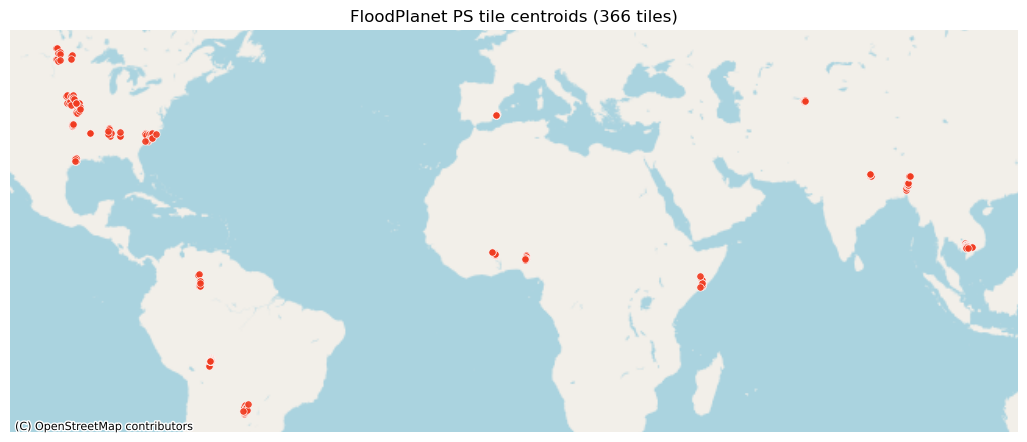

In [4]:
 
# Convert tile footprints to centroids so they remain visible at the global map scale.
plot_gdf = gdf.to_crs(epsg=3857)
centroid_gdf = plot_gdf.set_geometry(plot_gdf.geometry.centroid)

fig, ax = plt.subplots(figsize=(13, 9))
centroid_gdf.plot(
    ax=ax,
    color="#f03b20",
    edgecolor="white",
    linewidth=0.5,
    markersize=28,
    alpha=0.9,
    zorder=3,
)


ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)
 

ax.set_title(f"FloodPlanet PS tile centroids ({len(centroid_gdf):,} tiles)")
 

ax.set_axis_off()
plt.show()